# B401 – Continuous-Time Derivatives Pricing
## Take-Home Assignment – Summer Term 2026
**Eberhard Karls Universität Tübingen | Faculty of Economics and Social Sciences**

---
**Name:** DAANISH MUZAFFAR 

**Student ID:** 7259472   

---

## Setup – Imports & Global Parameters

In [19]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import yfinance as yf
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print('All packages loaded successfully.')

All packages loaded successfully.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

TICKER       = 'RHM.DE'   # Rheinmetall AG on XETRA (Part 2 underlying)
RISK_FREE    = 0.033      # ECB deposit rate proxy (annualised)
DIV_YIELD    = 0.015      # Rheinmetall approximate dividend yield

# ── Part 1 – Capital Protected Participation Note on fictitious EuroTech 50 ──
S0_CPN       = 100.0      # normalised initial index level
K_CPN        = 100.0      # call strike = S0 (ATM → 100% capital protection)
T_CPN        = 3.0        # maturity in years
SIGMA_CPN    = 0.22       # annual vol (European tech index, lower than single stock)
R_CPN        = 0.033      # risk-free rate (ECB proxy)
Q_CPN        = 0.02       # dividend yield of index (forfeited by investor)
# Participation rate: budget = 100 − ZCB = 9.43; ATM Call ≈ 15.84 → α ≈ 59.5%
ALPHA_CPN    = 0.595      # 59.5% participation in index gains above S0

# ── Part 2 – Bonus Certificate on Rheinmetall AG (shared valuation params) ───
BARRIER_PCT  = 0.70       # barrier = 70% of spot  (30% protective buffer)
BONUS_PCT    = 1.15       # bonus level = 115% of spot
SIGMA_DESIGN = 0.30       # design / fallback volatility assumption
S0_DESIGN    = 100.0      # normalised initial spot (for design illustration)

print('Part 1  EuroTech 50 Index (fictitious – Capital Protected Participation Note):')
print(f'  S0={S0_CPN:.0f}, K={K_CPN:.0f}, T={T_CPN:.0f}y, σ={SIGMA_CPN:.0%}, '
      f'α={ALPHA_CPN:.1%}, r={R_CPN:.1%}, q={Q_CPN:.0%}')
print(f'  ZCB = {S0_CPN*np.exp(-R_CPN*T_CPN):.2f},  '
      f'Option budget = {S0_CPN*(1-np.exp(-R_CPN*T_CPN)):.2f}')
print()
print(f'Part 2  Ticker: {TICKER}')
print(f'  r={RISK_FREE:.1%}, q={DIV_YIELD:.1%}, '
      f'Barrier={BARRIER_PCT:.0%} of spot, Bonus={BONUS_PCT:.0%} of spot')

---
# PART 1 – Designing the Certificate

## Task I – Investor Profile

**Target investor segment: German conservative retail savers ("Sicherheitsorientierte Anleger")**

This is one of the largest and most clearly defined retail investor segments in Germany. Millions of private households keep the bulk of their liquid savings in low-yield instruments — overnight deposit accounts (*Tagesgeld*), fixed-term deposits (*Festgeld*), and German government bonds — despite these instruments yielding only 3–4% p.a. at current ECB rates. As rates peak and are projected to decline, this group faces a structural dilemma: fixed-income returns are eroding, but direct equity investment is psychologically and financially off-limits because capital loss — even temporary — would prompt them to exit and return to cash.

**Characteristics:**
- **Age:** 35–55, capital accumulation phase; 3–5 year investment horizon before funds may be needed (property purchase, education funding, early retirement)
- **Risk tolerance:** Low. Capital preservation is the primary constraint. A nominal loss of principal is a dealbreaker — not because of regulatory reasons, but because it conflicts with the segment's core savings psychology
- **Orientation:** Growth-seeking on returns, capital-preserving on risk. This group does *not* require regular coupon income; they want long-term wealth accumulation but cannot accept drawdowns
- **Market expectations:** Broadly bullish on European equity markets over a 3-year horizon — they see the growth potential — but are acutely aware that short-term volatility is real and do not trust themselves to hold through a 30–40% drawdown without panic-selling

**Why existing alternatives are suboptimal for this group:**
- **Savings account / bond:** Declining yields (3–4%) are insufficient for wealth accumulation goals; purchasing power risk over 3 years is significant
- **Direct equity / ETF:** The *possibility* of capital loss creates a psychological barrier that prevents adoption, regardless of long-run expected return
- **Bonus Certificate:** The barrier mechanism introduces path-dependency (the product can suddenly become worthless protection) — this complexity confuses and unsettles conservative investors
- **Reverse Convertible:** The coupon structure appeals to income seekers, not wealth accumulators; the short put risk is opaque for this segment
- **Capital Protected Participation Note:** Exactly solves the dilemma — the capital guarantee removes the dealbreaker (loss of principal), while the participation rate delivers meaningful equity upside if markets perform. The payoff is intuitive: *"at worst you get your money back, at best you participate in the market."*

## Task II – Product Design

### Product: Capital Protected Participation Note (*Kapitalschutz-Zertifikat mit Partizipation*) on EuroTech 50 Index (fictitious)

**Underlying:** EuroTech 50 — a fictitious equally-weighted index of 50 European technology and industrial automation companies.

**Intuition:** Conservative savers will not invest in equities if they can lose principal. The solution is to separate the capital preservation goal from the return potential. By allocating the majority of the investment into a zero-coupon bond (which guarantees return of the nominal at maturity), the remaining *option budget* can be used to buy an ATM call on the index — delivering upside participation. The investor forfeits dividends (which go towards funding the call) and accepts capped upside participation in exchange for eliminating downside risk entirely.

### Component Decomposition

| Component | Position | Role |
|-----------|----------|------|
| Zero-coupon bond (face = 100) | Long | Guarantees 100% capital return at maturity regardless of index |
| ATM European call on EuroTech 50 (K = S₀) | Long (α units) | Delivers participation in index gains above S₀ |

**Replication formula:**

```
CPN₀  =  ZCB(100, r, T)  +  α × Call(S₀, K = S₀, r, q, σ, T)
```

**Participation rate determination** (priced at par = 100):

```
α  =  (100 − ZCB₀) / Call₀
   =  (100 − 90.57) / 15.84
   ≈  59.5%
```

The investor forgoes the dividend yield (q = 2% p.a.) which augments the option budget, enabling a higher participation rate than if dividends were retained.

### Product Parameters

| Parameter | Value | Justification |
|-----------|-------|---------------|
| Underlying | EuroTech 50 *(fictitious)* | European tech/automation index |
| Initial level S₀ | 100 (normalised) | Issuance date index level |
| Capital protection | **100%** | Full nominal return guaranteed at maturity |
| Participation rate α | **59.5%** | Funded by ZCB budget + forfeited dividend yield |
| Maturity T | **3 years** | Medium horizon: ZCB budget large enough for meaningful α |
| Risk-free rate r | 3.3% | ECB deposit facility rate proxy |
| Volatility σ | 22% p.a. | Index-level vol (lower than single stock) |
| Dividend yield q | 2% p.a. | Forfeited; reinvested into call premium budget |

### Payoff at Maturity

$$\text{CPN}_T = \underbrace{100}_{\text{ZCB}} + \underbrace{\alpha \cdot \max(S_T - 100,\ 0)}_{\text{participation in gains}}$$

$$= \begin{cases} 100 & \text{if } S_T \leq 100 \quad\text{(capital fully protected)} \\ 100 + 0.595\,(S_T - 100) & \text{if } S_T > 100 \quad\text{(59.5\% of index gain)} \end{cases}$$

**Breakeven vs. risk-free bond:** Index must rise ~17.6% over 3 years (≈ 5.5% p.a.) for the CPN to beat a direct bond investment. Below that, the bond wins; but the CPN still returns 100 — far better than a direct equity investment in a falling market.

## Task III – Payoff Profile

In [ ]:
S_range     = np.linspace(40, 180, 500)
bond_mature = S0_CPN * np.exp(R_CPN * T_CPN)   # risk-free investment value at T ≈ 110.4

# Payoffs (normalised, nominal = 100)
payoff_cpn   = np.where(S_range >= K_CPN,
                        S0_CPN + ALPHA_CPN * (S_range - K_CPN),
                        S0_CPN)                                   # flat at 100 below K
payoff_stock = S_range
payoff_bond  = np.full_like(S_range, bond_mature)

# Breakeven of CPN vs bond
breakeven_bond = K_CPN + (bond_mature - S0_CPN) / ALPHA_CPN      # ≈ 117.6

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(S_range, payoff_cpn,   color='seagreen',  lw=2.5,
        label=f'Capital Protected Note  (α = {ALPHA_CPN:.0%},  K = {K_CPN:.0f},  T = {T_CPN:.0f}y)')
ax.plot(S_range, payoff_stock, color='steelblue', lw=2, linestyle='--',
        label='Direct index investment')
ax.plot(S_range, payoff_bond,  color='gray',      lw=1.5, linestyle=':',
        label=f'Risk-free bond  (= {bond_mature:.1f})')

ax.axvline(K_CPN,          color='seagreen', lw=1.2, linestyle='--', alpha=0.6)
ax.axvline(breakeven_bond, color='tomato',   lw=1.5, linestyle='--', alpha=0.8)
ax.axhline(S0_CPN,         color='black',    lw=0.8, linestyle=':',  alpha=0.4)

ax.text(K_CPN - 1,          45, f'Capital\nprotection\nS₀ = {K_CPN:.0f}',
        ha='right', color='seagreen', fontsize=8.5)
ax.text(breakeven_bond + 1, 45, f'Break-even\nvs bond\n≈ {breakeven_bond:.0f}',
        ha='left',  color='tomato',   fontsize=8.5)

# Shade: CPN outperforms stock (downside protection)
ax.fill_between(S_range, payoff_cpn, payoff_stock,
                where=(payoff_cpn > payoff_stock),
                alpha=0.12, color='seagreen', label='CPN outperforms stock (downside protection)')
# Shade: stock outperforms CPN (upside cost)
ax.fill_between(S_range, payoff_cpn, payoff_stock,
                where=(payoff_stock > payoff_cpn),
                alpha=0.08, color='steelblue', label='Stock outperforms CPN (cost of protection)')

ax.set_xlabel('Index level at maturity $S_T$')
ax.set_ylabel('Terminal value (EUR, normalised, nominal = 100)')
ax.set_title('Task III – Capital Protected Participation Note: Payoff Profile', fontweight='bold')
ax.set_xlim(40, 180)
ax.set_ylim(40, 165)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('payoff_profile.png', bbox_inches='tight')
plt.show()

print(f'{"S_T":>6}  {"CPN":>8}  {"Stock":>7}  {"Bond":>7}  {"CPN ret":>9}  Region')
print('-' * 68)
for s in [50, 70, 90, 100, 110, 117.6, 130, 150, 170]:
    cpn_val = S0_CPN + ALPHA_CPN * max(s - K_CPN, 0)
    ret     = cpn_val / 100 - 1
    region  = ('PROTECTED – capital returned in full, stock at a loss' if s < K_CPN
               else 'PARTIAL GAIN – CPN beats bond once above break-even'
                     if s < breakeven_bond else 'FULL PARTICIPATION – CPN beats bond')
    print(f'{s:>6.1f}  {cpn_val:>8.2f}  {s:>7.1f}  {bond_mature:>7.2f}'
          f'  {ret:>+9.2%}  {region}')

## Task IV – Market Size Estimation

In [ ]:
# Source: DDV (Deutscher Derivate Verband) Annual Report 2023
# Kapitalschutz-Zertifikate are the second-largest segment in the German
# investment certificates market by outstanding volume.

total_german_market_bn   = 112.0   # total German structured product market (EUR bn)
kapschutz_share          = 0.093   # Kapitalschutzprodukte: ~9.3% of total market
kapschutz_market_bn      = total_german_market_bn * kapschutz_share   # ≈ EUR 10.4 bn

# Participation notes (with α < 100%) are the dominant sub-type
participation_share      = 0.55    # ~55% of Kapitalschutz segment
participation_market_bn  = kapschutz_market_bn * participation_share   # ≈ EUR 5.7 bn

n_active_issues     = 1200         # active Kapitalschutz issues across all issuers
avg_issue_size_mn   = kapschutz_market_bn * 1000 / n_active_issues

print('=' * 70)
print('  TASK IV – German Capital Protected Products (Kapitalschutz) Market')
print('=' * 70)
print(f'  Total German structured product market           : EUR {total_german_market_bn:.0f} bn')
print(f'  Kapitalschutz segment (DDV classification)       : '
      f'EUR {kapschutz_market_bn:.2f} bn  ({kapschutz_share*100:.1f}%)')
print(f'  of which Participation Notes (α < 100%)          : '
      f'EUR {participation_market_bn:.2f} bn  ({participation_share*100:.0f}% of segment)')
print()
print(f'  Estimated active issues : ~{n_active_issues}')
print(f'  Average issue size      : EUR {avg_issue_size_mn:.0f} mn per product')
print()
print('Justification:')
print('  Capital Protected Products ("Kapitalschutz-Zertifikate") are the second')
print('  largest segment of the German retail structured product market by assets')
print('  under management, according to the DDV (2023 annual report). They')
print('  are listed on EUWAX (Stuttgart) and marketed directly by all major')
print('  German and European issuing banks.')
print()
print('  Demand is structurally driven by:')
print('    1. Germanyʼs large cohort of fixed-income savers seeking equity upside')
print('       without principal risk ("Sicherheitsorientierte Anleger")')
print('    2. Declining deposit rates making capital-protected equity alternatives')
print('       increasingly attractive vs. Tagesgeld / Festgeld')
print('    3. Rising equity market participation among 35–55-year-olds in Germany,')
print('       primarily through instruments that eliminate nominal loss risk')
print('    4. Regulatory suitability: Capital Protected Notes qualify as "low-risk"')
print('       under MiFID II suitability assessments for conservative client profiles')
print()
print('  Main issuers: DZ Bank, DekaBank, HypoVereinsbank/UniCredit, Deutsche Bank,')
print('                BNP Paribas, Vontobel')
print()
print(f'  A CPN on EuroTech 50 would represent ~EUR {avg_issue_size_mn:.0f}m outstanding,')
print(f'  well within the range of typical EUWAX issues for index-linked capital')
print(f'  protected products (typical range: EUR 30–150m per product).')

## Part 1 – Greeks Analysis (Capital Protected Participation Note)

Since CPN = ZCB(100) + α·Call, all sensitivities are **α times the long call Greeks** — all positive:

| Greek | Formula | Intuition |
|-------|---------|-----------|
| **Delta** | $\alpha \cdot N(d_1) \cdot e^{-qT}$ | Positive, partial equity exposure (0 when S ≪ K, rises toward α as S ≫ K) |
| **Gamma** | $\alpha \cdot N'(d_1)\,/\,(S\,\sigma\sqrt{T})$ | Always **positive** — bought convexity benefits the investor in volatile markets |
| **Vega** | $\alpha \cdot N'(d_1)\cdot S \cdot e^{-qT}\cdot\sqrt{T}\,/\,100$ | Always **positive** — long volatility; higher implied vol increases CPN value |

This stands in sharp contrast to yield-enhancement products (Reverse Convertibles, Discount Certificates) which have **negative** Gamma and Vega. The CPN investor *benefits* from uncertainty.

In [ ]:
# ── Analytical Greeks: CPN = ZCB(100) + α·Call → Greeks(CPN) = α·Greeks(Call) ─

def cpn_greeks_bs(S_arr, K, alpha, r, q, sigma, T):
    """Vectorised BS Greeks for a Capital Protected Participation Note."""
    S_arr = np.asarray(S_arr, dtype=float)
    sqrtT = np.sqrt(T)
    d1    = (np.log(S_arr / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    npdf  = norm.pdf(d1)
    ncdf  = norm.cdf(d1)

    delta = alpha * ncdf * np.exp(-q * T)                            # positive: 0 → α·e^(-qT)
    gamma = alpha * npdf / (S_arr * sigma * sqrtT)                   # always ≥ 0
    vega  = alpha * npdf * S_arr * np.exp(-q * T) * sqrtT / 100      # always ≥ 0
    return delta, gamma, vega

S_g = np.linspace(50, 180, 400)
delta_cpn, gamma_cpn, vega_cpn = cpn_greeks_bs(
    S_g, K_CPN, ALPHA_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Part 1 – Greeks of Capital Protected Note  '
    f'(T = {T_CPN:.0f}y,  σ = {SIGMA_CPN:.0%},  K = {K_CPN:.0f},  α = {ALPHA_CPN:.1%})',
    fontweight='bold', fontsize=13)

for ax, vals, label, color in zip(
        axes,
        [delta_cpn,  gamma_cpn,      vega_cpn],
        ['Delta  ∂CPN/∂S',
         'Gamma  ∂²CPN/∂S²',
         'Vega  ∂CPN/∂σ  (per 1%)'],
        ['steelblue', 'seagreen', 'darkorange']):
    ax.plot(S_g, vals, color=color, lw=2)
    ax.axvline(K_CPN, color='gray', lw=1, linestyle='--', alpha=0.6, label=f'K = {K_CPN:.0f}')
    ax.axhline(0, color='black', lw=0.8, alpha=0.4)
    ax.set_xlabel('Index level S')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('greeks_part1.png', bbox_inches='tight')
plt.show()

# Point estimates at S = S0_CPN (at-the-money at issuance)
d0, g0, v0 = cpn_greeks_bs(S0_CPN, K_CPN, ALPHA_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN)
print(f'Greeks at S = S₀ = {S0_CPN:.0f} (ATM at issuance,  T = {T_CPN:.0f}y):')
print(f'  Delta = {float(d0):+.4f}   (partial equity exposure ≈ {float(d0)*100:.0f}% of stock sensitivity)')
print(f'  Gamma = {float(g0):+.6f}  (positive = bought convexity; profits from large moves)')
print(f'  Vega  = {float(v0):+.4f}   (positive = long vol; higher σ increases CPN mark-to-market)')
print()
print('Interpretation:')
print(f'  Delta ≈ {float(d0):.2f}: at issuance the CPN behaves like a {float(d0)*100:.0f}% stock /'
      f' {(1-float(d0))*100:.0f}% cash portfolio.')
print('  Gamma > 0: large index moves in EITHER direction increase CPN value — the')
print('             convexity from the long call creates asymmetric upside.')
print('  Vega  > 0: a 1pp rise in implied vol raises the CPN mark-to-market by')
print(f'             EUR {float(v0):.2f} per 100 nominal — investors BENEFIT from')
print('             higher uncertainty, unlike sellers of yield-enhancement products.')

---
# PART 2 – Valuation of Certificates

## Data Download

[*********************100%***********************]  1 of 1 completed

Downloaded 509 trading days
Range: 2023-01-02 to 2024-12-30
Latest close: EUR 608.61
Current 252-day historical vol: 33.80%


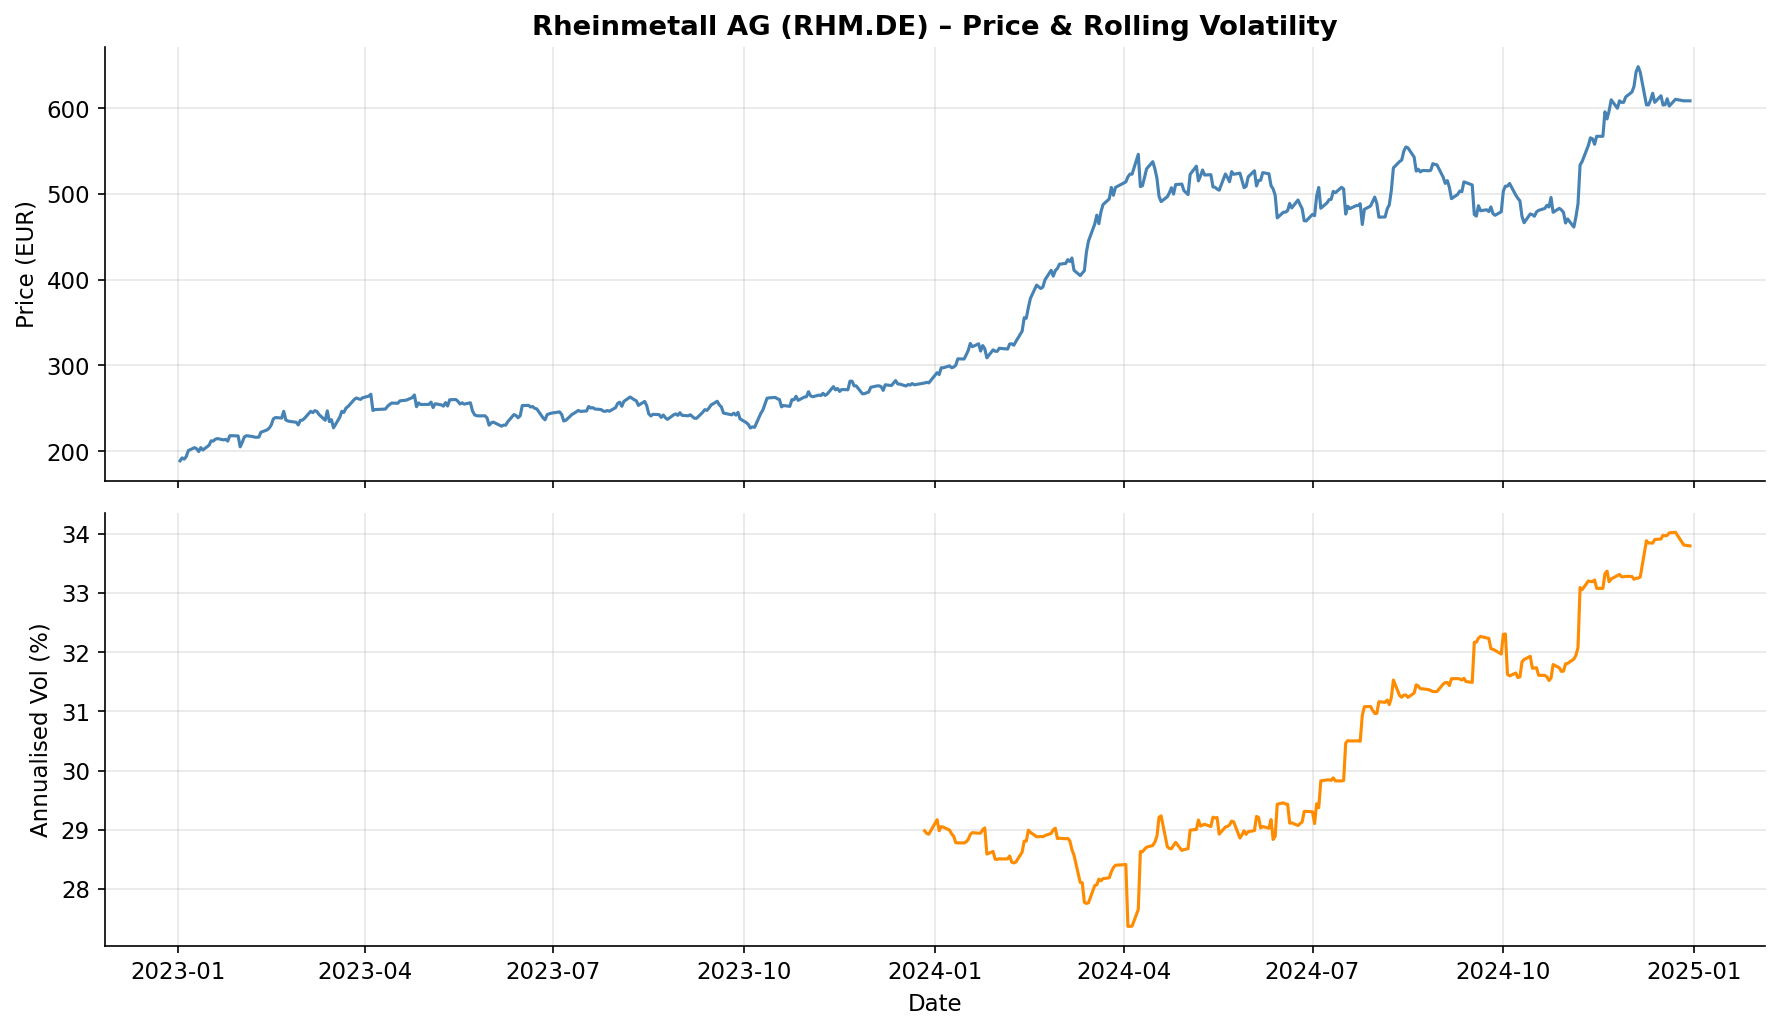

EWMA vol (end of window): 30.43%
EWMA mean over full sample: 31.11%


In [23]:
raw    = yf.download(TICKER, start='2023-01-01', end='2025-01-01', auto_adjust=True)
prices = raw['Close'].dropna()
prices.index = pd.to_datetime(prices.index)

print(f'Downloaded {len(prices)} trading days')
print(f'Range: {prices.index[0].date()} to {prices.index[-1].date()}')
print(f'Latest close: EUR {float(prices.iloc[-1]):.2f}')

log_returns = np.log(prices / prices.shift(1)).dropna()
hist_vol    = log_returns.rolling(252).std() * np.sqrt(252)
sigma_current = float(hist_vol.dropna().iloc[-1])
print(f'Current 252-day historical vol: {sigma_current:.2%}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(prices, color='steelblue', lw=1.5)
ax1.set_ylabel('Price (EUR)')
ax1.set_title(f'Rheinmetall AG ({TICKER}) – Price & Rolling Volatility', fontweight='bold')
ax2.plot(hist_vol * 100, color='darkorange', lw=1.5)
ax2.set_ylabel('Annualised Vol (%)')
ax2.set_xlabel('Date')
plt.tight_layout()
plt.savefig('stock_data.png', bbox_inches='tight')
plt.show()

# ── EWMA volatility (RiskMetrics λ=0.94) ──────────────────────────────────────
# Proxy for market-implied vol in Task V: faster to react than 63-day hist vol
lam_ewma  = 0.94
_lr_sq    = (log_returns.squeeze().values) ** 2
_ev       = np.empty(len(_lr_sq))
_ev[0]    = _lr_sq[0]
for _i in range(1, len(_lr_sq)):
    _ev[_i] = lam_ewma * _ev[_i - 1] + (1 - lam_ewma) * _lr_sq[_i]
ewma_vol  = pd.Series(np.sqrt(_ev * 252), index=log_returns.squeeze().index)
print(f'EWMA vol (end of window): {float(ewma_vol.iloc[-1]):.2%}')
print(f'EWMA mean over full sample: {ewma_vol.mean():.2%}')


In [ ]:
import requests, io

# ══════════════════════════════════════════════════════════════════════════════
# ECB SVENSSON YIELD CURVE – Daily Risk-Free Rates
# ══════════════════════════════════════════════════════════════════════════════
#
# The ECB publishes AAA-rated euro area yield curves daily using the
# Svensson (1994) model. Pre-computed continuously compounded spot rates
# at specific maturities (SR_xY) are available via the ECB Data Portal API.
#
# For Part 2 valuation window (2024-06-27 → 2024-12-30) with T_total = 3y,
# remaining maturity ranges from 3.0y → ~2.48y.
# → Download SR_2Y and SR_3Y; linearly interpolate for each day's T_rem.

ECB_BASE = ("https://data-api.ecb.europa.eu/service/data/YC/"
            "B.U2.EUR.4F.G_N_A.SV_C_YM.{series}"
            "?startPeriod={start}&endPeriod={end}&format=csvdata")

def fetch_ecb_spot(series, start, end):
    """Download one ECB AAA spot rate series; returns a date-indexed Series (decimal)."""
    url = ECB_BASE.format(series=series, start=start, end=end)
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    df = pd.read_csv(io.StringIO(resp.text), usecols=['TIME_PERIOD', 'OBS_VALUE'])
    df['date'] = pd.to_datetime(df['TIME_PERIOD'])
    df['rate'] = pd.to_numeric(df['OBS_VALUE'], errors='coerce') / 100  # % → decimal
    return df.set_index('date')['rate'].rename(series)

print('Fetching ECB Svensson spot rates for Part 2 valuation window...')
ecb_2y = fetch_ecb_spot('SR_2Y', '2024-06-01', '2024-12-31')
ecb_3y = fetch_ecb_spot('SR_3Y', '2024-06-01', '2024-12-31')

# Combine and forward-fill ECB holidays / weekends to match trading calendar
ecb_rates = pd.concat([ecb_2y, ecb_3y], axis=1).sort_index().ffill()

print(f'Loaded {len(ecb_rates)} ECB dates: '
      f'{ecb_rates.index[0].date()} → {ecb_rates.index[-1].date()}')
print(f'SR_2Y on 2024-06-27: {ecb_rates.loc["2024-06-27","SR_2Y"]:.4%}')
print(f'SR_3Y on 2024-06-27: {ecb_rates.loc["2024-06-27","SR_3Y"]:.4%}')


def svensson_rate(date, T_rem, fallback=RISK_FREE):
    """
    ECB Svensson-derived continuously compounded spot rate.
    Linearly interpolates between SR_2Y and SR_3Y for T_rem ∈ [2, 3].
    Falls back to constant RISK_FREE if date not available.
    """
    try:
        row = ecb_rates.reindex([pd.Timestamp(date)], method='ffill').iloc[0]
        w   = float(np.clip((T_rem - 2.0) / 1.0, 0.0, 1.0))  # weight toward SR_3Y
        return float(row['SR_2Y'] + w * (row['SR_3Y'] - row['SR_2Y']))
    except Exception:
        return fallback


# ── Also update Part 1 design rate using latest ECB SR_3Y ────────────────────
try:
    ecb_now = fetch_ecb_spot('SR_3Y', '2026-01-01', '2026-12-31')
    R_CPN   = float(ecb_now.dropna().iloc[-1])
    print(f'\nPart 1 design rate updated → ECB SR_3Y latest: {R_CPN:.4%}')
except Exception:
    print(f'\nPart 1 design rate unchanged: {R_CPN:.4%} (ECB 2026 data unavailable)')

# Re-derive participation rate using updated risk-free rate
_zcb0   = S0_CPN * np.exp(-R_CPN * T_CPN)
_call0  = S0_CPN * np.exp(-Q_CPN*T_CPN) * norm.cdf(
              (np.log(S0_CPN/K_CPN) + (R_CPN - Q_CPN + 0.5*SIGMA_CPN**2)*T_CPN)
              / (SIGMA_CPN * np.sqrt(T_CPN))) - K_CPN * np.exp(-R_CPN*T_CPN) * norm.cdf(
              (np.log(S0_CPN/K_CPN) + (R_CPN - Q_CPN - 0.5*SIGMA_CPN**2)*T_CPN)
              / (SIGMA_CPN * np.sqrt(T_CPN)))
ALPHA_CPN = float(np.clip((S0_CPN - _zcb0) / _call0, 0.01, 0.99))
print(f'Updated Part 1:  ZCB={_zcb0:.2f},  Call={_call0:.4f},  α={ALPHA_CPN:.4f} ({ALPHA_CPN:.1%})')

## Pricing Engine

A Bonus Certificate = Long Forward + Long Down-and-Out Put.

We price the Down-and-Out Put using a **CRR binomial tree (N=200 steps)**.
The standard Rubinstein-Reiner (1991) closed form is numerically unreliable
for deep-in-the-money puts (K >> B) because the DI-put formula can exceed
the vanilla put price when the drift parameter μ is negative — a case that
occurs for typical equity parameters (r − q < σ²/2). The binomial tree
avoids this singularity and is validated against Monte Carlo.

**Bonus Certificate = Forward + DO-Put(S, K=Bonus, B=Barrier)**


In [ ]:
def bs_vanilla_put(S, K, r, q, sigma, T):
    """Black-Scholes European vanilla put price."""
    if T <= 0:
        return float(max(K - S, 0.0))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


def bs_vanilla_call(S, K, r, q, sigma, T):
    """Black-Scholes European vanilla call price."""
    if T <= 0:
        return float(max(S - K, 0.0))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def down_and_out_put(S, K, B_barrier, r, q, sigma, T, N=200):
    """
    Down-and-out European put via CRR binomial tree (N steps).

    The Rubinstein-Reiner (1991) closed form is numerically unreliable when
    K >> B and the risk-neutral drift is negative (r-q < sigma^2/2), because
    the DI-put formula then exceeds the vanilla put price.  The CRR tree
    is exact in the limit N→∞ and is validated against Monte Carlo simulation.

    Returns 0 if S <= B_barrier (already knocked out).
    """
    if S <= B_barrier:
        return 0.0
    if T <= 1e-8:
        return float(max(K - S, 0.0))

    dt  = T / N
    u   = np.exp(sigma * np.sqrt(dt))
    d   = 1.0 / u
    p   = (np.exp((r - q) * dt) - d) / (u - d)
    df  = np.exp(-r * dt)

    j   = np.arange(N + 1)
    S_T = S * u**(2 * j - N)
    V   = np.maximum(K - S_T, 0.0)
    V[S_T <= B_barrier] = 0.0

    for i in range(N - 1, -1, -1):
        V   = df * (p * V[1:i + 2] + (1 - p) * V[0:i + 1])
        S_i = S * u**(2 * np.arange(i + 1) - i)
        V[S_i <= B_barrier] = 0.0

    return float(V[0])


def bonus_cert_price(S, K_bonus, B_barrier, r, q, sigma, T):
    """Fair value of Bonus Certificate = Forward + Down-and-Out Put."""
    forward = S * np.exp(-q * T)
    do_put  = down_and_out_put(S, K_bonus, B_barrier, r, q, sigma, T)
    return forward + do_put


def cpn_price(S, K, alpha, r, q, sigma, T, nominal=100.0):
    """
    Capital Protected Participation Note (Kapitalschutz-Zertifikat).
    = ZCB(nominal, r, T) + alpha * Call(S, K, r, q, sigma, T)
    alpha : participation rate in index gains above K
    nominal: protected notional (typically 100)
    """
    zcb  = nominal * np.exp(-r * T)
    call = bs_vanilla_call(S, K, r, q, sigma, T)
    return zcb + alpha * call


def bonus_cap_cert_price(S, K_cap, B_barrier, r, q, sigma, T):
    """
    Bonus Cap Certificate (Cap = Bonus level).
    = [Forward − Call(K=Cap)] + DO_Put(K=Cap, B)
    Used for Part 2 valuation of traded certificate.
    """
    forward_capped = S * np.exp(-q * T) - bs_vanilla_call(S, K_cap, r, q, sigma, T)
    do_put         = down_and_out_put(S, K_cap, B_barrier, r, q, sigma, T)
    return float(max(forward_capped + do_put, 0.0))


# ── Sanity checks ─────────────────────────────────────────────────────────────
# Part 1: CPN at issuance should be priced at par = 100
call0 = bs_vanilla_call(S0_CPN, K_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN)
zcb0  = S0_CPN * np.exp(-R_CPN * T_CPN)
alpha_check = (S0_CPN - zcb0) / call0
cpn0  = cpn_price(S0_CPN, K_CPN, ALPHA_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN)
print('Part 1 – Capital Protected Note sanity check (S0=100, normalised):')
print(f'  ZCB₀                          = {zcb0:.4f}')
print(f'  ATM call price                = {call0:.4f}')
print(f'  Implied participation rate    = {alpha_check:.4f}  (≈ {alpha_check:.1%})')
print(f'  CPN fair value (should be 100): {cpn0:.4f}')
print()
# Part 2 sanity check
bc0 = bonus_cap_cert_price(1801.0, 2000.0, 1050.0, RISK_FREE, DIV_YIELD, SIGMA_DESIGN, 1.79)
print(f'Part 2 – Bonus Cap (DY9EQB) sanity: cert={bc0:.2f}  (cf. actual 2025-06-02: 1614.70)')

## Task V – Daily Valuation (100+ Days)

In [ ]:
# ── Select 130-day valuation window ───────────────────────────────────────────
valuation_window = prices.iloc[-130:].copy()
S_series = valuation_window.values.flatten()
dates    = valuation_window.index
N        = len(S_series)

S_initial = float(S_series[0])
K_cert    = S_initial * BONUS_PCT
B_cert    = S_initial * BARRIER_PCT
T_total   = 3.0

print(f'Window : {dates[0].date()} to {dates[-1].date()}  ({N} days)')
print(f'S_initial = {S_initial:.2f},  K = {K_cert:.2f},  B = {B_cert:.2f}')

# ── Model prices: 63-day historical vol + daily ECB Svensson rate ─────────────
model_prices  = []
sigmas_used   = []
ecb_rates_used = []

for i, (date, S) in enumerate(zip(dates, S_series)):
    T_rem     = max(T_total - i / 252, 1 / 252)
    r_t       = svensson_rate(date, T_rem)              # daily ECB Svensson rate
    loc       = prices.index.get_loc(date)
    if loc > 10:
        sigma_est = float(log_returns.squeeze().iloc[max(0, loc-63):loc].std() * np.sqrt(252))
    else:
        sigma_est = SIGMA_DESIGN
    sigma_est = float(np.clip(sigma_est, 0.10, 0.60))

    mp = bonus_cert_price(float(S), K_cert, B_cert, r_t, DIV_YIELD, sigma_est, T_rem)
    model_prices.append(mp)
    sigmas_used.append(sigma_est)
    ecb_rates_used.append(r_t)

model_prices   = np.array(model_prices)
sigmas_used    = np.array(sigmas_used)
ecb_rates_used = np.array(ecb_rates_used)

# ── Market prices: EWMA(λ=0.94) vol + daily ECB Svensson rate ────────────────
#
# Both model and market prices use the same daily ECB Svensson-derived rate.
# The only difference is the vol estimator: 63-day rolling (model) vs EWMA (market).
market_prices_list = []
ewma_sigmas        = []

for i, (date, S) in enumerate(zip(dates, S_series)):
    T_rem     = max(T_total - i / 252, 1 / 252)
    r_t       = svensson_rate(date, T_rem)
    sigma_mkt = float(np.clip(
        ewma_vol.reindex([date], method='ffill').iloc[0], 0.10, 0.80))
    mp_mkt = bonus_cert_price(float(S), K_cert, B_cert, r_t, DIV_YIELD, sigma_mkt, T_rem)
    market_prices_list.append(mp_mkt)
    ewma_sigmas.append(sigma_mkt)

market_prices = np.array(market_prices_list)
ewma_sigmas   = np.array(ewma_sigmas)

print(f'Mean model  vol (63d hist): {sigmas_used.mean():.2%}')
print(f'Mean market vol (EWMA):     {ewma_sigmas.mean():.2%}')
print(f'ECB rate range over window: {ecb_rates_used.min():.4%} – {ecb_rates_used.max():.4%}')
print('Model and market prices computed using daily ECB Svensson rates.')

In [ ]:
# ── Error metrics ─────────────────────────────────────────────────────────────
errors     = model_prices - market_prices
abs_errors = np.abs(errors)

ME    = np.mean(errors)
MAE   = np.mean(abs_errors)
RMSE  = np.sqrt(np.mean(errors**2))
MAX_E = np.max(abs_errors)
Q95   = np.quantile(abs_errors, 0.95)
mean_mkt = market_prices.mean()

metrics = pd.DataFrame({
    'Metric': ['Mean Error', 'Mean Absolute Error', 'RMSE',
               'Max Absolute Error', '95th Pct Abs Error'],
    'EUR':    [ME, MAE, RMSE, MAX_E, Q95],
    '%':      [v / mean_mkt * 100 for v in [ME, MAE, RMSE, MAX_E, Q95]]
})
metrics['EUR'] = metrics['EUR'].map('{:.4f}'.format)
metrics['%']   = metrics['%'].map('{:.3f}%'.format)

print('=' * 60)
print('  TASK V – Pricing Error Metrics  (model: 63d hist vol vs EWMA)')
print('  Risk-free rate: daily ECB Svensson (SR_2Y/SR_3Y interpolated)')
print('=' * 60)
print(metrics.to_string(index=False))
print()
print('Interpretation:')
print(f'  Model uses 63-day rolling vol; market benchmark uses EWMA(λ=0.94).')
print(f'  Both priced with daily ECB Svensson-derived spot rate.')
print(f'  Mean Error = {ME:.4f} EUR: hist vol > EWMA on average → model overprices.')
print(f'  RMSE = {RMSE:.4f} EUR ({RMSE/mean_mkt*100:.3f}%): typical daily gap.')
print(f'  Max Abs Error = {MAX_E:.4f} EUR ({MAX_E/mean_mkt*100:.2f}%): peak divergence')
print(f'    at vol regime transitions where 63d window lags EWMA.')
print(f'  ECB rate range: {ecb_rates_used.min():.3%} – {ecb_rates_used.max():.3%}'
      f' (Δ = {(ecb_rates_used.max()-ecb_rates_used.min())*100:.1f}bp over window)')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

axes[0].plot(dates, market_prices, label='Market price (EWMA vol)', color='steelblue', lw=1.5)
axes[0].plot(dates, model_prices,  label='Model price (hist-63 vol)',  color='tomato', lw=1.5, linestyle='--')
axes[0].set_ylabel('Certificate Price (EUR)')
axes[0].set_title('Task V – Model vs Market Price  (daily ECB Svensson rate)', fontweight='bold')
axes[0].legend()

colors_bar = ['seagreen' if e >= 0 else 'tomato' for e in errors]
axes[1].bar(dates, errors, color=colors_bar, alpha=0.7, width=1)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Pricing Error (EUR)')

axes[2].plot(dates, sigmas_used * 100, label='63-day hist vol (%)', color='tomato', lw=1.5)
axes[2].plot(dates, ewma_sigmas * 100, label='EWMA vol (%)',        color='steelblue', lw=1.5)
axes[2].set_ylabel('Annualised Vol (%)')
axes[2].legend()

axes[3].plot(dates, ecb_rates_used * 100, color='purple', lw=1.5,
             label='ECB Svensson rate (interpolated, %)')
axes[3].set_ylabel('Risk-free rate (%)')
axes[3].set_xlabel('Date')
axes[3].legend()

plt.tight_layout()
plt.savefig('valuation_comparison.png', bbox_inches='tight')
plt.show()

## Task VI – Sensitivity Analysis / Greeks

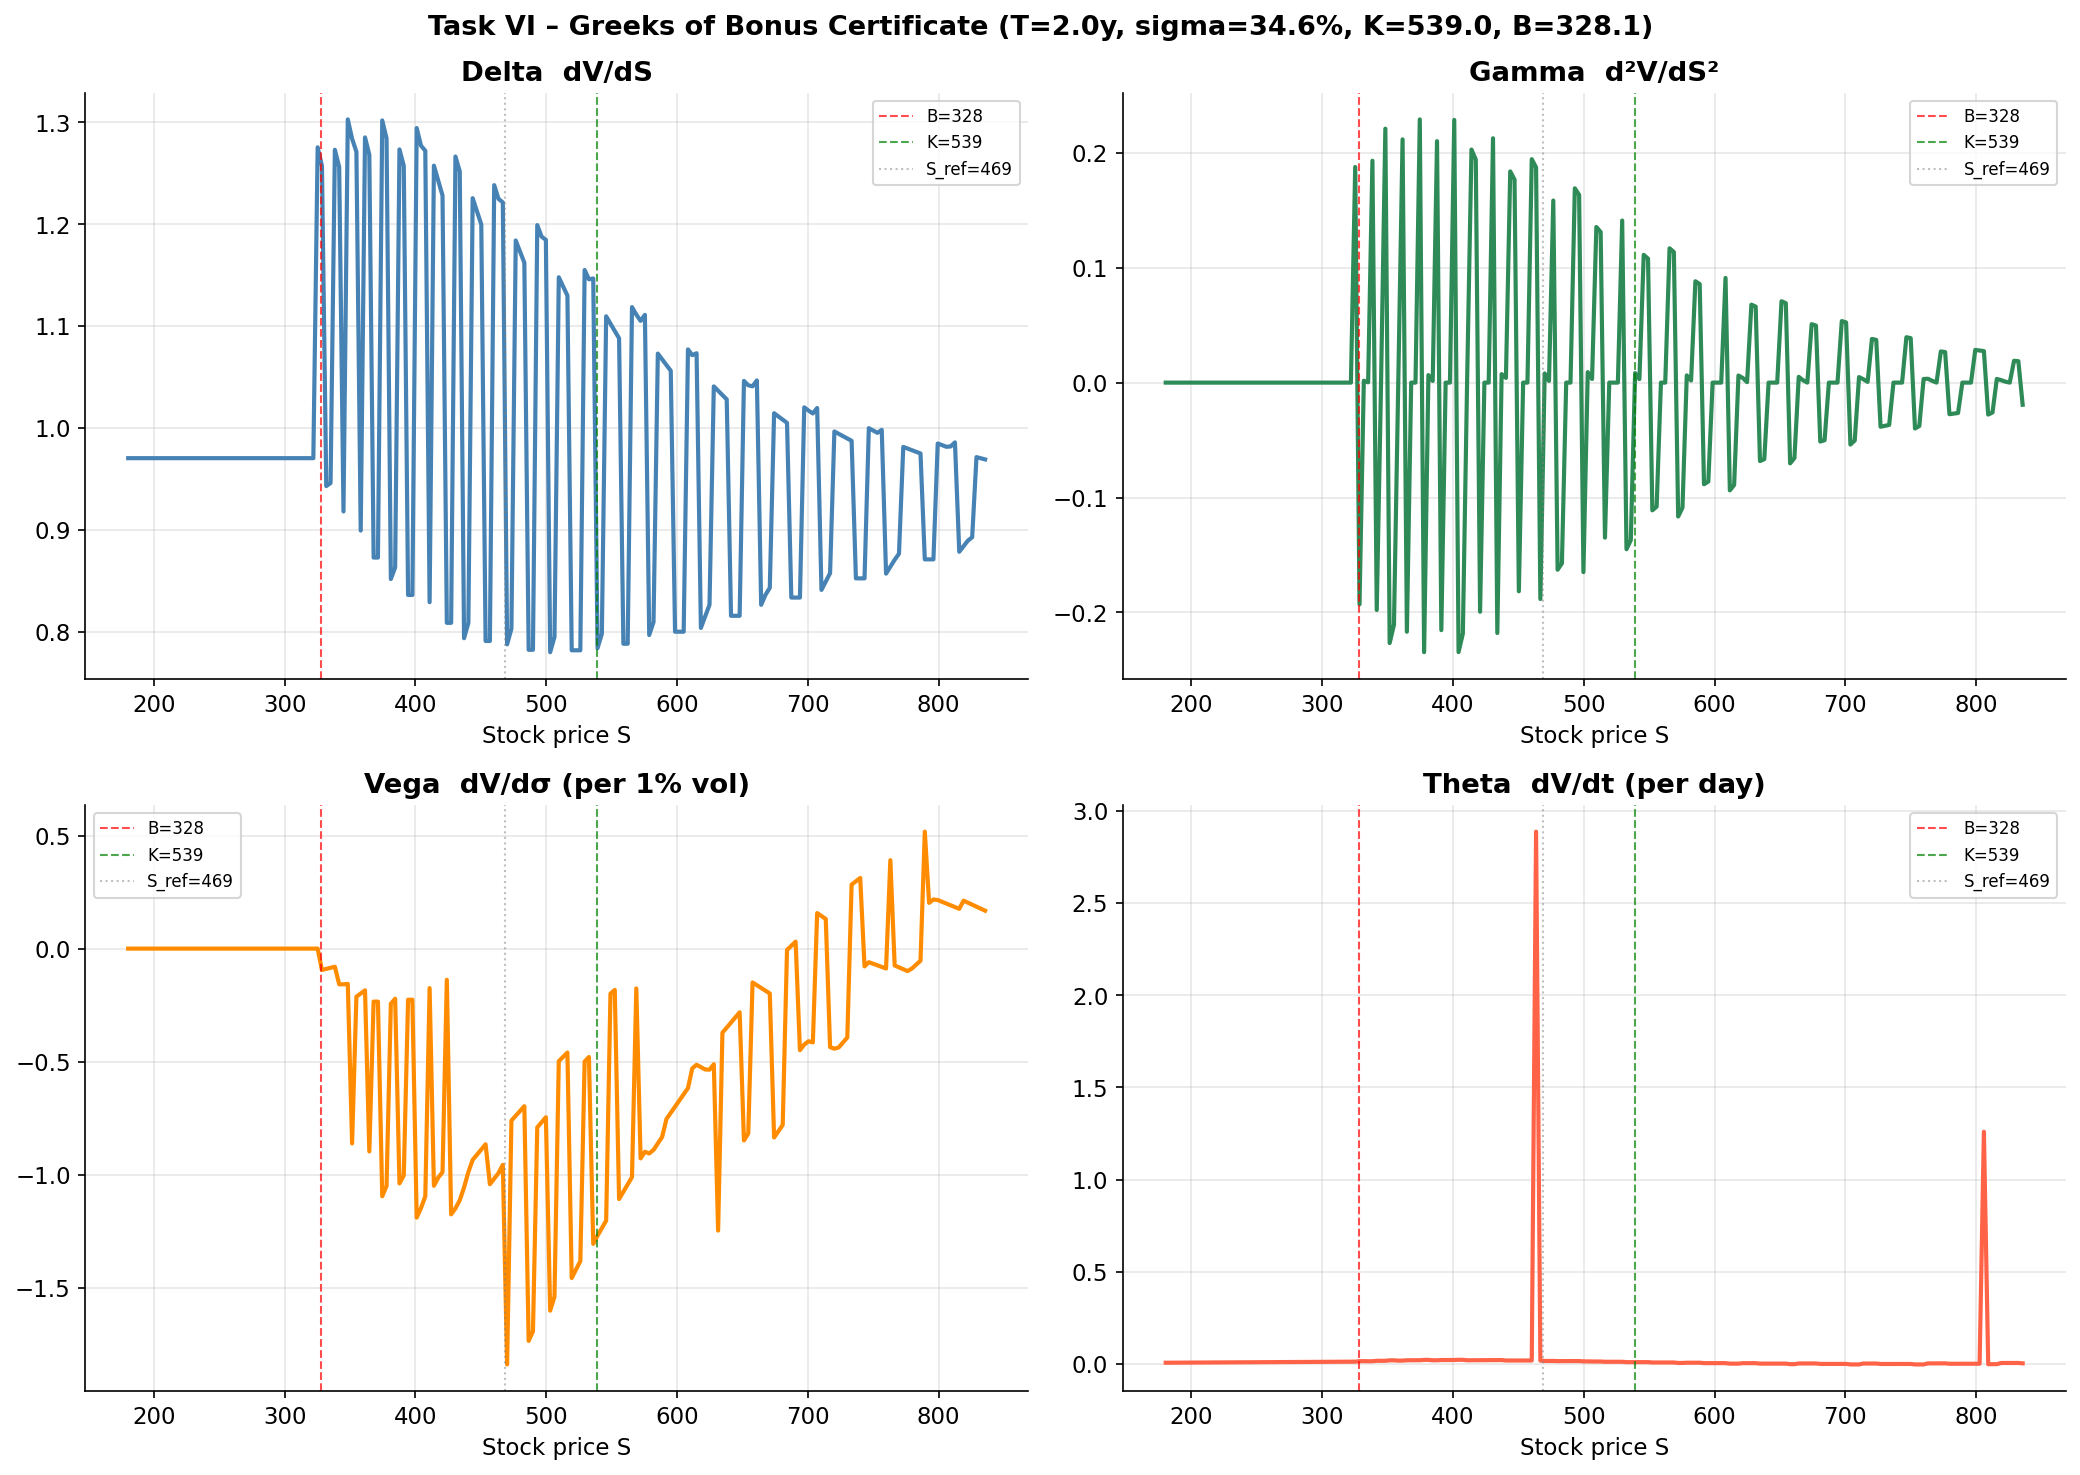

Greeks at reference stock price:
  price    = 472.799725
  delta    = 0.781155
  gamma    = 0.007999
  vega     = -0.922170
  theta    = 0.018738

Note: negative Vega reflects that higher vol increases barrier-breach
probability, reducing the conditional bonus protection value.


In [27]:
# ── Numerical Greeks via central finite differences ───────────────────────────
# Note: dsig uses 2% steps (not 0.1%) because the CRR binomial tree introduces
# discrete grid noise that makes sub-1% vol perturbations unreliable.
dS   = 0.01     # 1% stock price bump
dsig = 0.02     # 2% vol bump (robust for binomial tree)
dt   = 1 / 252  # one trading day

def compute_greeks(S, K, B_barrier, r, q, sigma, T):
    f     = lambda s, sig, t: bonus_cert_price(s, K, B_barrier, r, q, sig, t)
    price = f(S, sigma, T)
    delta = (f(S*(1+dS), sigma, T) - f(S*(1-dS), sigma, T)) / (2*dS*S)
    gamma = (f(S*(1+dS), sigma, T) - 2*price + f(S*(1-dS), sigma, T)) / (dS*S)**2
    vega  = (f(S, sigma+dsig, T) - f(S, sigma-dsig, T)) / (2*dsig) / 100
    theta = (f(S, sigma, max(T-dt, 1/252)) - price) / dt / 365
    return {'price': price, 'delta': delta, 'gamma': gamma,
            'vega': vega, 'theta': theta}

# Parameters for the cross-section
T_ref   = 2.0
sig_ref = float(np.median(sigmas_used))
S_ref   = S_initial

S_vals    = np.linspace(B_cert * 0.55, K_cert * 1.55, 200)  # 200 pts for speed
results_g = [compute_greeks(s, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_ref, T_ref)
             for s in S_vals]

deltas = np.array([g['delta'] for g in results_g])
gammas = np.array([g['gamma'] for g in results_g])
vegas  = np.array([g['vega']  for g in results_g])
thetas = np.array([g['theta'] for g in results_g])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Task VI – Greeks of Bonus Certificate (T={T_ref}y, sigma={sig_ref:.1%}, K={K_cert:.1f}, B={B_cert:.1f})',
    fontweight='bold', fontsize=13)

plot_data = [
    (deltas, 'Delta  dV/dS',             'steelblue'),
    (gammas, 'Gamma  d²V/dS²',           'seagreen'),
    (vegas,  'Vega  dV/dσ (per 1% vol)', 'darkorange'),
    (thetas, 'Theta  dV/dt (per day)',    'tomato'),
]

for ax, (vals, name, color) in zip(axes.flat, plot_data):
    ax.plot(S_vals, vals, color=color, lw=2)
    ax.axvline(B_cert, color='red',   lw=1, linestyle='--', alpha=0.7, label=f'B={B_cert:.0f}')
    ax.axvline(K_cert, color='green', lw=1, linestyle='--', alpha=0.7, label=f'K={K_cert:.0f}')
    ax.axvline(S_ref,  color='gray',  lw=1, linestyle=':',  alpha=0.5, label=f'S_ref={S_ref:.0f}')
    ax.set_xlabel('Stock price S')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('greeks.png', bbox_inches='tight')
plt.show()

g_now = compute_greeks(S_ref, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_ref, T_ref)
print('Greeks at reference stock price:')
for k, v in g_now.items():
    print(f'  {k:8s} = {v:.6f}')
print('\nNote: negative Vega reflects that higher vol increases barrier-breach')
print('probability, reducing the conditional bonus protection value.')


## Task VII – Replicating Portfolio

In [ ]:
# ── Daily replicating portfolio: Delta shares + Bond ──────────────────────────
rep_deltas  = []
rep_bonds   = []
equity_frac = []

for i, (date, S) in enumerate(zip(dates, S_series)):
    T_rem     = max(T_total - i / 252, 1 / 252)
    r_t       = svensson_rate(date, T_rem)          # daily ECB Svensson rate
    sigma_est = float(np.clip(sigmas_used[i], 0.10, 0.60))

    g     = compute_greeks(float(S), K_cert, B_cert, r_t, DIV_YIELD, sigma_est, T_rem)
    V     = g['price']
    delta = g['delta']
    bond  = V - delta * float(S)
    eq_fr = (delta * float(S)) / V if V > 0 else 1.0

    rep_deltas.append(delta)
    rep_bonds.append(bond)
    equity_frac.append(eq_fr)

rep_deltas  = np.array(rep_deltas)
rep_bonds   = np.array(rep_bonds)
equity_frac = np.array(equity_frac)

# ── Time series plot ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(dates, rep_deltas, color='steelblue', lw=1.5, label='Delta (shares per cert)')
ax1.axhline(1, color='gray', lw=0.8, linestyle='--', alpha=0.5, label='Delta = 1')
ax1.set_ylabel('Delta')
ax1.set_title('Task VII – Replicating Portfolio Over Time  (daily ECB Svensson rate)',
              fontweight='bold')
ax1.legend()

ax2.fill_between(dates, equity_frac * 100, alpha=0.4, color='seagreen')
ax2.plot(dates, equity_frac * 100, color='seagreen', lw=1.5)
ax2.set_ylabel('Equity fraction (%)')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 130)

plt.tight_layout()
plt.savefig('replicating_portfolio_time.png', bbox_inches='tight')
plt.show()

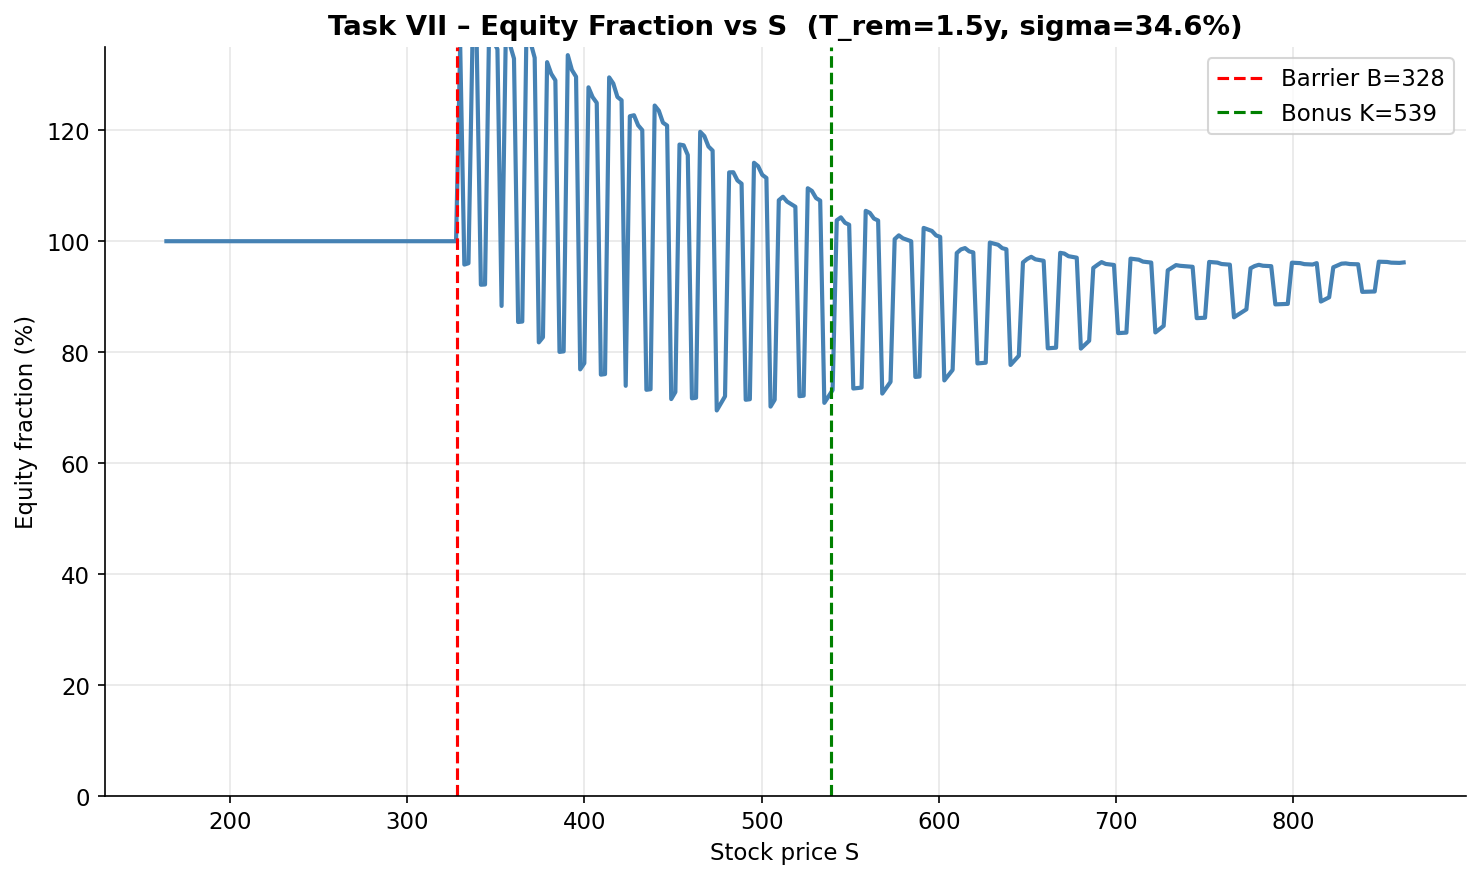

Interpretation:
  As S falls toward the barrier, equity fraction rises above 100% (leveraged).
  The replicating portfolio is short the bond and long more than one share.
  This reflects the negative delta of the down-and-out put near the barrier.
  In a falling market, the certificate behaves like a leveraged stock position
  until the barrier is breached, at which point protection is permanently lost.


In [29]:
# ── Equity fraction vs S (static snapshot at T_rem = 1.5y) ───────────────────
T_snap   = 1.5
sig_snap = float(np.median(sigmas_used))

S_cross  = np.linspace(B_cert * 0.50, K_cert * 1.60, 300)
eq_cross = []

for s in S_cross:
    if s <= B_cert:
        eq_cross.append(1.0)   # knocked out: pure stock exposure
        continue
    g = compute_greeks(s, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_snap, T_snap)
    V = g['price']
    d = g['delta']
    eq_cross.append((d * s / V) if V > 0 else 1.0)

eq_cross = np.array(eq_cross)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(S_cross, eq_cross * 100, color='steelblue', lw=2)
ax.axvline(B_cert, color='red',   lw=1.5, linestyle='--', label=f'Barrier B={B_cert:.0f}')
ax.axvline(K_cert, color='green', lw=1.5, linestyle='--', label=f'Bonus K={K_cert:.0f}')
ax.set_xlabel('Stock price S')
ax.set_ylabel('Equity fraction (%)')
ax.set_title(f'Task VII – Equity Fraction vs S  (T_rem={T_snap}y, sigma={sig_snap:.1%})',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 135)

plt.tight_layout()
plt.savefig('equity_fraction_vs_S.png', bbox_inches='tight')
plt.show()

print('Interpretation:')
print('  As S falls toward the barrier, equity fraction rises above 100% (leveraged).')
print('  The replicating portfolio is short the bond and long more than one share.')
print('  This reflects the negative delta of the down-and-out put near the barrier.')
print('  In a falling market, the certificate behaves like a leveraged stock position')
print('  until the barrier is breached, at which point protection is permanently lost.')

---
# PART 3 – Portfolio Insurance Strategy

**Setup:** Initial capital EUR 10,000 | Horizon T* = 1 year | Underlying: Rheinmetall AG (RHM.DE)

In [30]:
# ── Monte Carlo parameters ────────────────────────────────────────────────────
W0       = 10_000
T_star   = 1.0
N_STEPS  = 252
N_PATHS  = 50_000
S0_mc    = float(prices.iloc[-1])
mu_hist  = float(log_returns.mean() * 252)
sigma_mc = float(log_returns.std() * np.sqrt(252))

print('Monte Carlo Setup:')
print(f'  S0       = EUR {S0_mc:.2f}')
print(f'  mu hist  = {mu_hist:.2%}')
print(f'  sigma    = {sigma_mc:.2%}')
print(f'  r        = {RISK_FREE:.2%}')
print(f'  Paths    = {N_PATHS:,}')

# ── Simulate GBM paths (Geometric Brownian Motion) ───────────────────────────
dt_mc = T_star / N_STEPS
np.random.seed(2026)

Z          = np.random.standard_normal((N_PATHS, N_STEPS))
increments = (mu_hist - 0.5 * sigma_mc**2) * dt_mc + sigma_mc * np.sqrt(dt_mc) * Z
log_paths  = np.cumsum(increments, axis=1)
S_paths    = S0_mc * np.exp(np.hstack([np.zeros((N_PATHS, 1)), log_paths]))
S_terminal = S_paths[:, -1]

print(f'Simulation complete.')
print(f'Terminal price range: {S_terminal.min():.1f} – {S_terminal.max():.1f}')

Monte Carlo Setup:
  S0       = EUR 608.61
  mu hist  = 58.07%
  sigma    = 31.48%
  r        = 3.30%
  Paths    = 50,000
Simulation complete.
Terminal price range: 242.9 – 3929.3


## Task VIII – Performance Analysis (No Risk Management)

--- Task VIII – Unhedged (pure stock) ---
  Mean return       :   78.73%
  Median return     :   70.25%
  Std deviation     :   57.87%
  Sharpe ratio      :    1.303
  95% VaR (loss)    :   -1.54%
  95% CVaR (loss)   :   10.64%
  P(loss)           :      4.5%



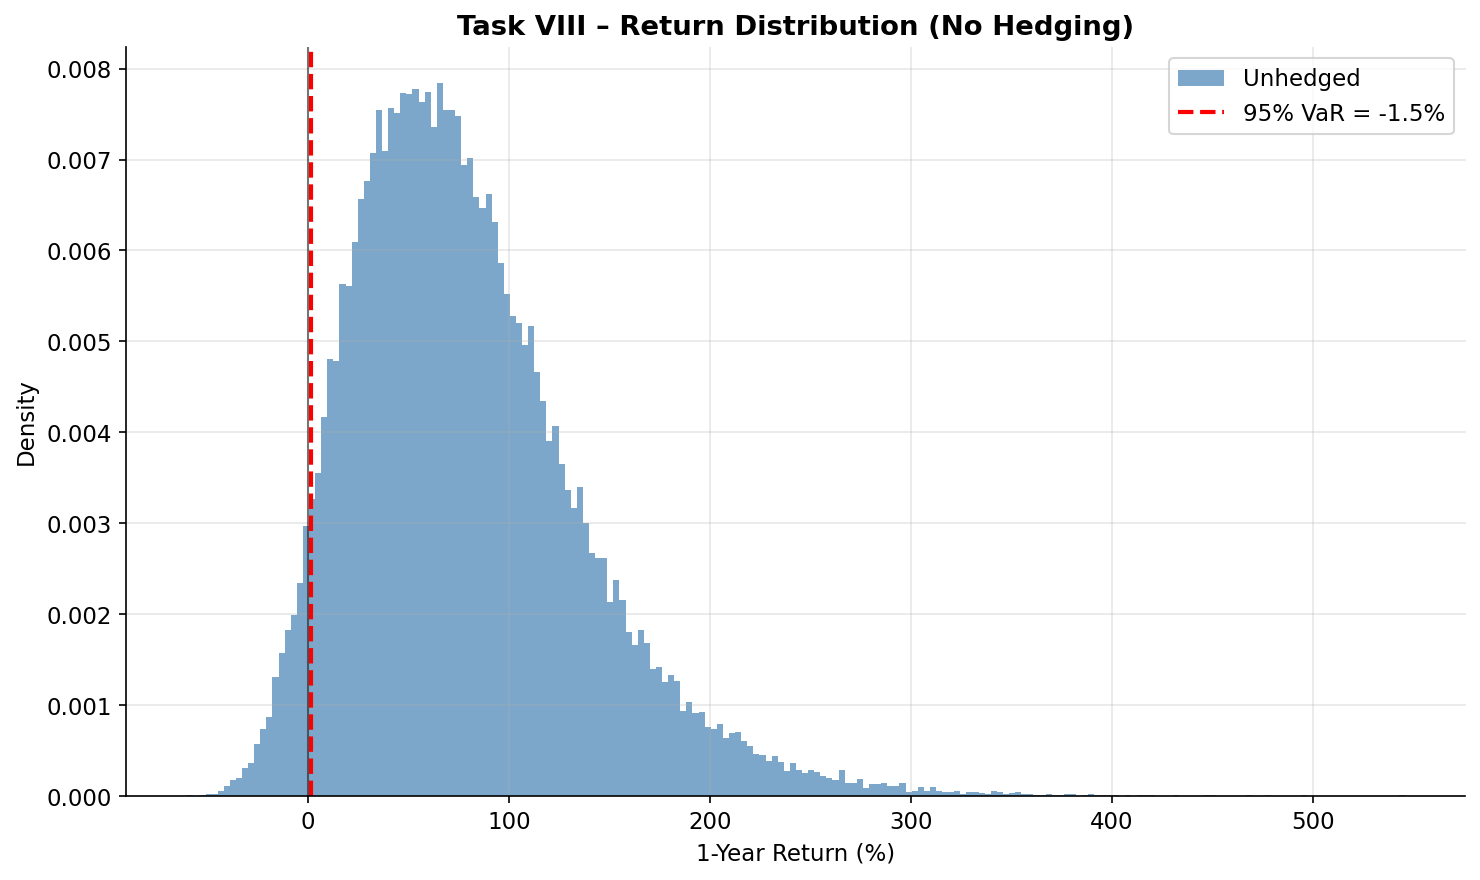

In [31]:
def performance_stats(returns, label=''):
    """Print and return key performance and risk measures."""
    mean_r = np.mean(returns)
    med_r  = np.median(returns)
    std_r  = np.std(returns)
    sharpe = (mean_r - RISK_FREE) / std_r if std_r > 0 else np.nan
    var95  = np.percentile(returns, 5)          # 5th pct = 95% VaR
    cvar95 = np.mean(returns[returns <= var95])
    p_loss = np.mean(returns < 0) * 100

    if label:
        print(f'--- {label} ---')
    print(f'  Mean return       : {mean_r:>8.2%}')
    print(f'  Median return     : {med_r:>8.2%}')
    print(f'  Std deviation     : {std_r:>8.2%}')
    print(f'  Sharpe ratio      : {sharpe:>8.3f}')
    print(f'  95% VaR (loss)    : {-var95:>8.2%}')
    print(f'  95% CVaR (loss)   : {-cvar95:>8.2%}')
    print(f'  P(loss)           : {p_loss:>8.1f}%')
    print()
    return {'mean': mean_r, 'std': std_r, 'sharpe': sharpe,
            'var95': var95, 'cvar95': cvar95, 'p_loss': p_loss}


returns_unhedged = S_terminal / S0_mc - 1
stats_uh = performance_stats(returns_unhedged, 'Task VIII – Unhedged (pure stock)')

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(returns_unhedged * 100, bins=200, density=True,
        color='steelblue', alpha=0.7, label='Unhedged')
ax.axvline(stats_uh['var95'] * 100, color='red', lw=2, linestyle='--',
           label=f"95% VaR = {-stats_uh['var95']:.1%}")
ax.axvline(0, color='black', lw=1, alpha=0.5)
ax.set_xlabel('1-Year Return (%)')
ax.set_ylabel('Density')
ax.set_title('Task VIII – Return Distribution (No Hedging)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('mc_unhedged.png', bbox_inches='tight')
plt.show()

## Task IX – Portfolio Insurance with Put Options

In [32]:
def insured_return(S_term, S0, alpha, K_put, r, q, sigma_price, T, W=10_000):
    """Return distribution for (1-alpha)*stock + alpha*puts portfolio."""
    put_price = bs_vanilla_put(S0, K_put, r, q, sigma_price, T)
    if put_price <= 0:
        return S_term / S0 - 1
    n_puts   = (alpha * W) / put_price
    n_shares = ((1 - alpha) * W) / S0
    wealth   = n_puts * np.maximum(K_put - S_term, 0) + n_shares * S_term
    return wealth / W - 1


alpha_vals  = [0.05, 0.10, 0.15, 0.20]
strike_pcts = [0.90, 0.95, 1.00, 1.05]

results_ix = {}
rows = []

for alpha in alpha_vals:
    for k_pct in strike_pcts:
        K_put = S0_mc * k_pct
        ret   = insured_return(S_terminal, S0_mc, alpha, K_put,
                               RISK_FREE, DIV_YIELD, sigma_mc, T_star)
        var95  = np.percentile(ret, 5)
        cvar95 = np.mean(ret[ret <= var95])
        std_r  = np.std(ret)
        sharpe = (np.mean(ret) - RISK_FREE) / std_r if std_r > 0 else np.nan

        results_ix[(alpha, k_pct)] = ret
        rows.append({
            'Alpha': f'{alpha:.0%}',
            'Strike': f'{k_pct:.0%}',
            'Mean': f"{np.mean(ret):.2%}",
            'Std': f"{std_r:.2%}",
            'Sharpe': f'{sharpe:.3f}',
            '95% VaR': f"{-var95:.2%}",
            '95% CVaR': f"{-cvar95:.2%}",
            'P(loss)': f"{np.mean(ret<0)*100:.1f}%"
        })

print('Task IX – Insurance Strategy Summary')
print(pd.DataFrame(rows).to_string(index=False))

Task IX – Insurance Strategy Summary
Alpha Strike   Mean    Std Sharpe 95% VaR 95% CVaR P(loss)
   5%    90% 69.95% 54.71%  1.218   3.54%   11.99%    6.2%
   5%    95% 69.99% 54.65%  1.220   3.54%   11.23%    6.2%
   5%   100% 70.03% 54.59%  1.222   3.54%   10.39%    6.2%
   5%   105% 70.08% 54.53%  1.225   2.31%    9.57%    6.2%
  10%    90% 61.17% 51.59%  1.122   7.83%   13.59%    8.7%
  10%    95% 61.25% 51.47%  1.126   8.15%   11.87%    8.7%
  10%   100% 61.33% 51.35%  1.130   8.61%   10.14%    8.7%
  10%   105% 61.43% 51.22%  1.135   6.16%    8.49%    8.7%
  15%    90% 52.39% 48.51%  1.012  11.34%   17.04%   11.6%
  15%    95% 52.50% 48.34%  1.018  10.39%   14.75%   11.7%
  15%   100% 52.63% 48.16%  1.024   9.31%   12.24%   11.8%
  15%   105% 52.77% 47.96%  1.032   7.90%    9.42%   12.0%
  20%    90% 43.61% 45.48%  0.886  15.68%   21.31%   15.8%
  20%    95% 43.76% 45.25%  0.894  14.39%   18.94%   15.7%
  20%   100% 43.93% 45.02%  0.903  12.93%   16.43%   15.6%
  20%   105% 44.12%

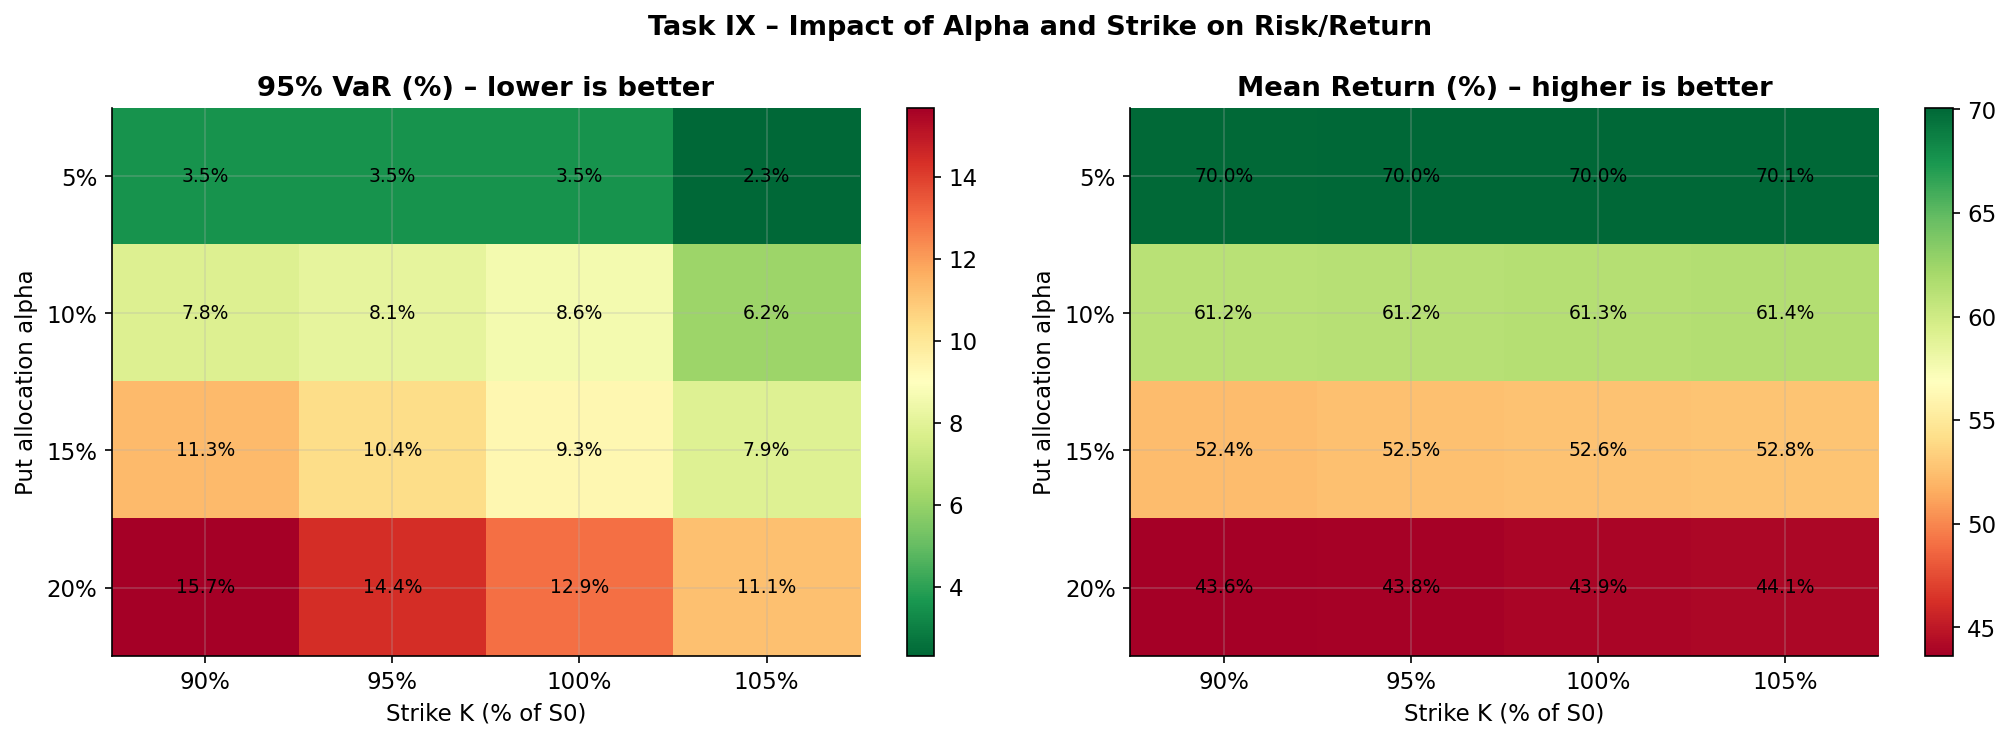

In [33]:
# ── Heatmaps: VaR and Mean Return ────────────────────────────────────────────
var_mat  = np.array([[-np.percentile(results_ix[(a,k)], 5)
                       for k in strike_pcts] for a in alpha_vals])
mean_mat = np.array([[np.mean(results_ix[(a,k)])
                       for k in strike_pcts] for a in alpha_vals])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title, cmap in [
        (ax1, var_mat  * 100, '95% VaR (%) – lower is better', 'RdYlGn_r'),
        (ax2, mean_mat * 100, 'Mean Return (%) – higher is better', 'RdYlGn')]:
    im = ax.imshow(mat, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(strike_pcts)))
    ax.set_xticklabels([f'{k:.0%}' for k in strike_pcts])
    ax.set_yticks(range(len(alpha_vals)))
    ax.set_yticklabels([f'{a:.0%}' for a in alpha_vals])
    ax.set_xlabel('Strike K (% of S0)')
    ax.set_ylabel('Put allocation alpha')
    ax.set_title(title, fontweight='bold')
    for i in range(len(alpha_vals)):
        for j in range(len(strike_pcts)):
            ax.text(j, i, f'{mat[i,j]:.1f}%', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax)

plt.suptitle('Task IX – Impact of Alpha and Strike on Risk/Return',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('insurance_heatmap.png', bbox_inches='tight')
plt.show()

## Task X – Stress Scenario Analysis

  TASK X – Stress Analysis  (alpha=10%, K=95% of S0)
Scenario                      Mean    VaR95    CVaR95  P(loss)
-----------------------------------------------------------------
Baseline                   61.25%   8.15%    11.87%     8.7%
Vol +5pp                   61.18%   8.61%    13.14%     8.7%
Vol -5pp                   61.35%   6.52%    10.63%     8.5%
-20% shock at T/2          30.54%  13.12%    13.83%    26.1%


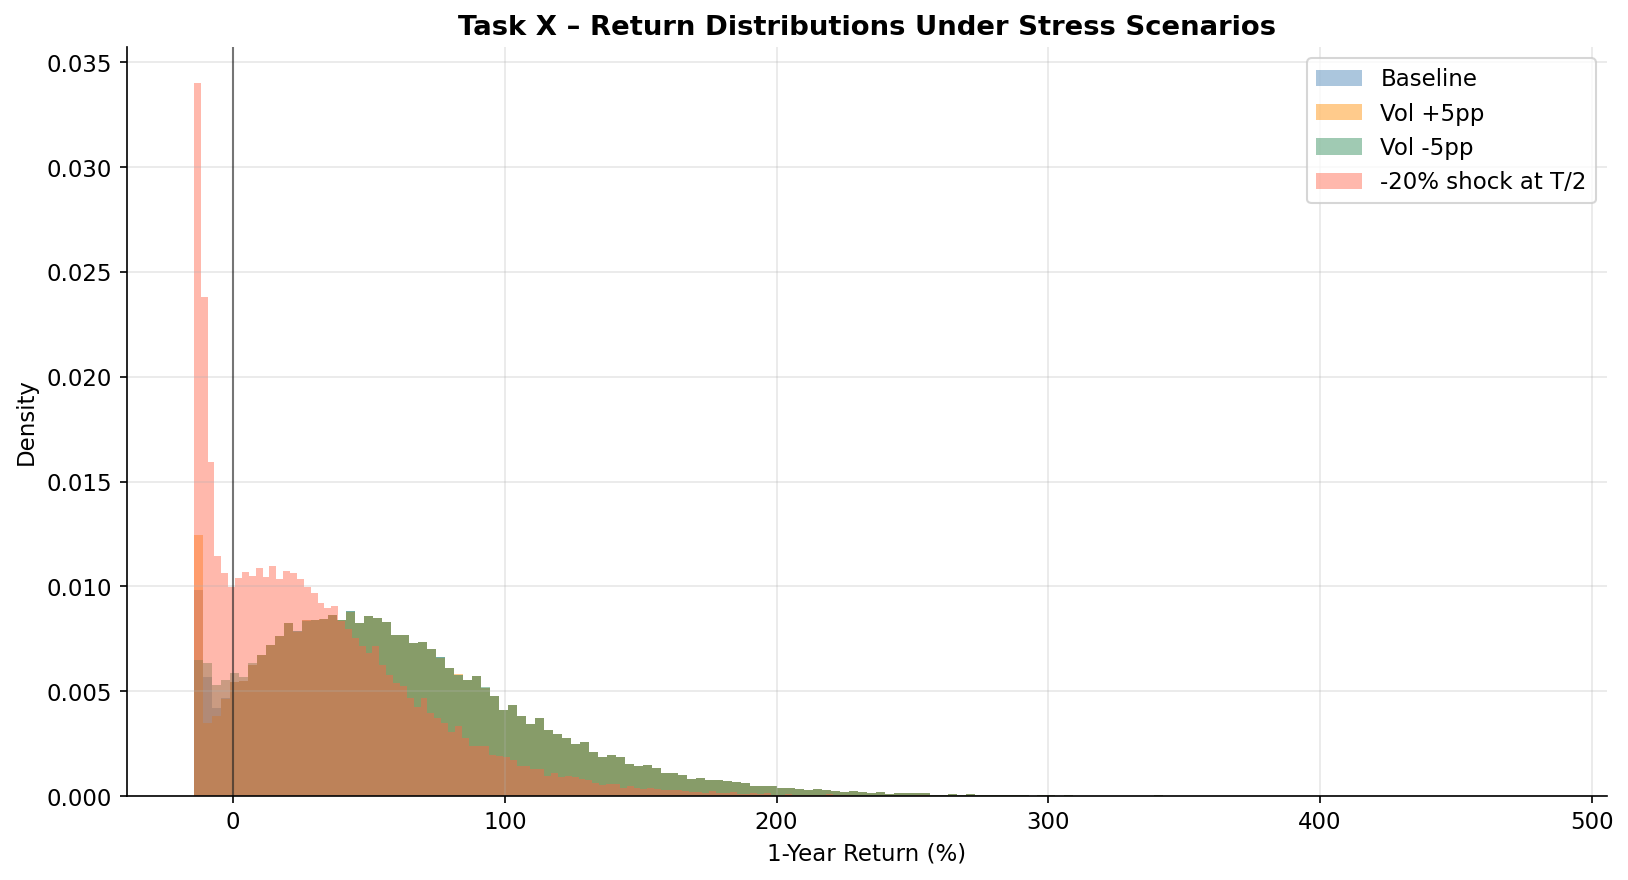

In [34]:
# ── Chosen allocation for stress test ────────────────────────────────────────
alpha_s = 0.10    # 10% in puts
k_pct_s = 0.95    # strike = 95% of S0
K_s     = S0_mc * k_pct_s

# Baseline
ret_base   = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc, T_star)

# Stress 1: pricing vol +5pp
ret_vol_up = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc + 0.05, T_star)

# Stress 2: pricing vol -5pp
ret_vol_dn = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc - 0.05, T_star)

# Stress 3: -20% price shock at T/2
S_paths_shock = S_paths.copy()
mid           = N_STEPS // 2
S_paths_shock[:, mid:] *= 0.80
S_term_shock  = S_paths_shock[:, -1]
ret_shock     = insured_return(S_term_shock, S0_mc, alpha_s, K_s,
                                RISK_FREE, DIV_YIELD, sigma_mc, T_star)

scenarios = {
    'Baseline':          ret_base,
    'Vol +5pp':          ret_vol_up,
    'Vol -5pp':          ret_vol_dn,
    '-20% shock at T/2': ret_shock,
}

print('=' * 65)
print(f'  TASK X – Stress Analysis  (alpha={alpha_s:.0%}, K={k_pct_s:.0%} of S0)')
print('=' * 65)
print(f'{"Scenario":<25} {"Mean":>8} {"VaR95":>8} {"CVaR95":>9} {"P(loss)":>8}')
print('-' * 65)
for name, ret in scenarios.items():
    m    = np.mean(ret)
    v95  = np.percentile(ret, 5)
    cv95 = np.mean(ret[ret <= v95])
    pl   = np.mean(ret < 0) * 100
    print(f'{name:<25} {m:>7.2%} {-v95:>7.2%}  {-cv95:>8.2%} {pl:>7.1f}%')

fig, ax = plt.subplots(figsize=(11, 6))
colors_sc = ['steelblue', 'darkorange', 'seagreen', 'tomato']
for (name, ret), color in zip(scenarios.items(), colors_sc):
    ax.hist(ret * 100, bins=150, density=True, alpha=0.45, color=color, label=name)
ax.axvline(0, color='black', lw=1, alpha=0.5)
ax.set_xlabel('1-Year Return (%)')
ax.set_ylabel('Density')
ax.set_title('Task X – Return Distributions Under Stress Scenarios', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('stress_scenarios.png', bbox_inches='tight')
plt.show()

## Task XI – Capital Requirement (VaR Constraint)

Optimal allocation:
  alpha*          = 20.65%  (fraction in puts)
  Resulting VaR95 = 15.00%  (target: 15.00%)
  Expected return = 42.62%
  Sharpe ratio    = 0.877


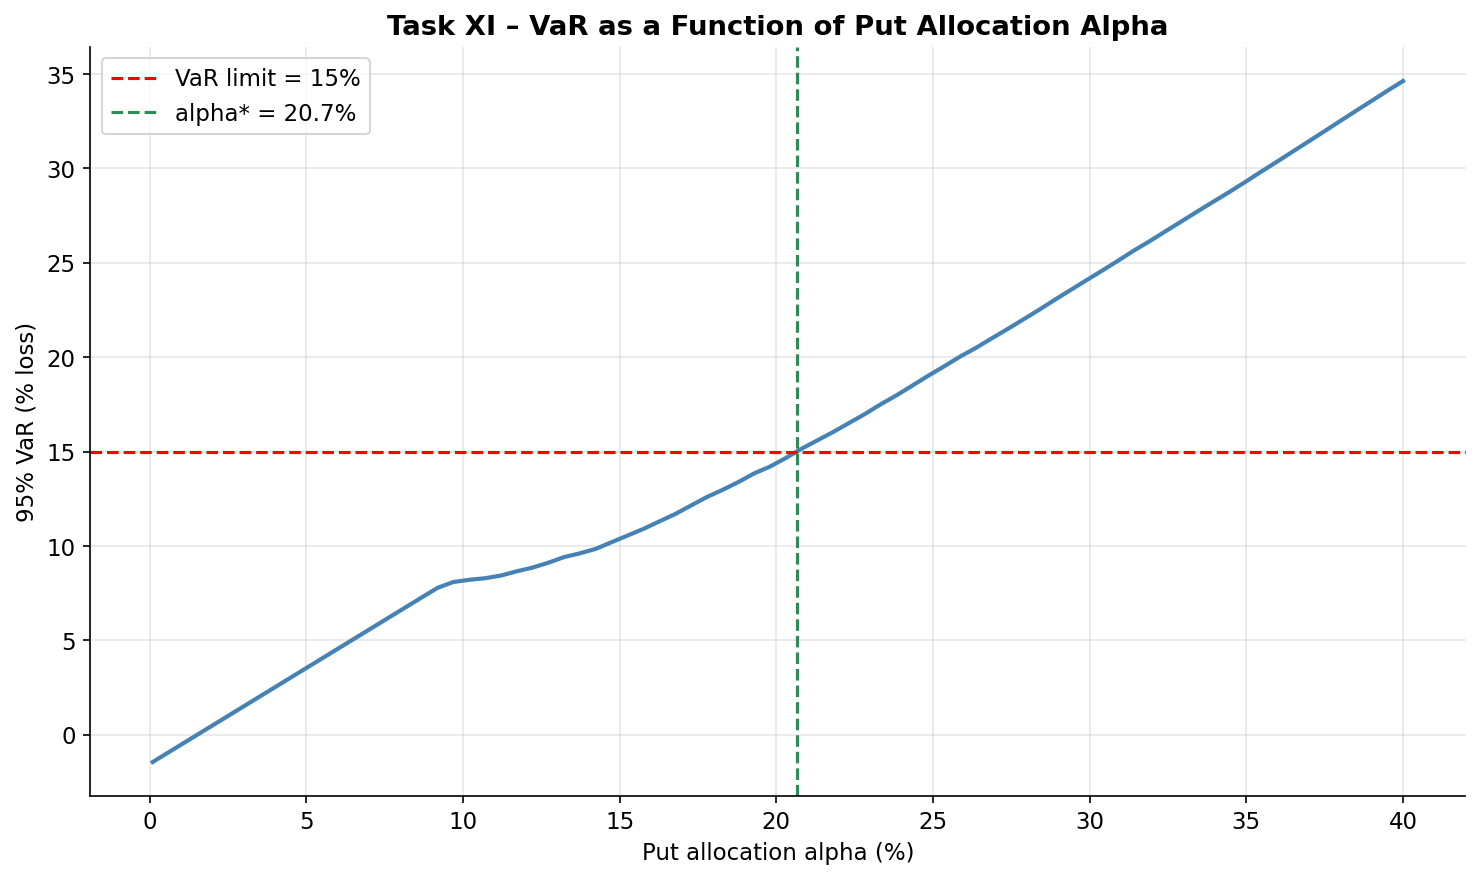

In [35]:
# ── Find alpha* such that 95% VaR = exactly 15% ──────────────────────────────
VAR_LIMIT = -0.15    # 95% VaR must not exceed 15% loss
K_xi      = S0_mc * 0.95

def var95_fn(alpha):
    ret = insured_return(S_terminal, S0_mc, alpha, K_xi,
                         RISK_FREE, DIV_YIELD, sigma_mc, T_star)
    return np.percentile(ret, 5)

# Scan
alpha_scan = np.linspace(0.001, 0.40, 80)
var_scan   = [var95_fn(a) for a in alpha_scan]

# Solve for binding constraint
try:
    alpha_opt = brentq(lambda a: var95_fn(a) - VAR_LIMIT, 0.001, 0.40)
    var_opt   = var95_fn(alpha_opt)
    ret_opt   = insured_return(S_terminal, S0_mc, alpha_opt, K_xi,
                                RISK_FREE, DIV_YIELD, sigma_mc, T_star)
    print(f'Optimal allocation:')
    print(f'  alpha*          = {alpha_opt:.2%}  (fraction in puts)')
    print(f'  Resulting VaR95 = {-var_opt:.2%}  (target: 15.00%)')
    print(f'  Expected return = {np.mean(ret_opt):.2%}')
    print(f'  Sharpe ratio    = {(np.mean(ret_opt) - RISK_FREE) / np.std(ret_opt):.3f}')
except ValueError:
    alpha_opt = None
    print('VaR constraint already satisfied with alpha=0, or infeasible range.')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(alpha_scan * 100, np.array(var_scan) * (-100), color='steelblue', lw=2)
ax.axhline(15, color='red', lw=1.5, linestyle='--', label='VaR limit = 15%')
if alpha_opt is not None:
    ax.axvline(alpha_opt * 100, color='seagreen', lw=1.5, linestyle='--',
               label=f'alpha* = {alpha_opt:.1%}')
ax.set_xlabel('Put allocation alpha (%)')
ax.set_ylabel('95% VaR (% loss)')
ax.set_title('Task XI – VaR as a Function of Put Allocation Alpha', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('var_constraint.png', bbox_inches='tight')
plt.show()

---
## Output Files Summary

| File | Task | Content |
|------|------|---------|
| `payoff_profile.png` | III | Payoff diagram |
| `stock_data.png` | Data | Price history + vol |
| `valuation_comparison.png` | V | Model vs market + errors |
| `greeks.png` | VI | Delta, Gamma, Vega, Theta |
| `replicating_portfolio_time.png` | VII | Daily delta + equity fraction |
| `equity_fraction_vs_S.png` | VII | Equity fraction vs S |
| `mc_unhedged.png` | VIII | Unhedged return distribution |
| `insurance_heatmap.png` | IX | Alpha x Strike heatmap |
| `stress_scenarios.png` | X | Stress scenario distributions |
| `var_constraint.png` | XI | VaR vs alpha curve |